<a href="https://colab.research.google.com/github/enikolaev/IT-and-Programming/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 11. Работа с изображениями. Библиотека Pillow

ФИО: **Николаев Евгений Иванович**

Группа: **ИНС-б-о-...**

## Задание

Загрузить изображение и продемонстрировать основные возможности библиотеки Pillow

## Анализ задания, получение данных

Выполним загрузку файла

In [1]:
!wget https://raw.githubusercontent.com/enikolaev/IT-and-Programming/refs/heads/main/data/pract11/cat.jpeg


--2026-09-18 08:49:49--  https://raw.githubusercontent.com/enikolaev/IT-and-Programming/refs/heads/main/data/pract11/cat.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 93715 (92K) [image/jpeg]
Saving to: ‘cat.jpeg’

cat.jpeg            100%[===================>]  91.52K  --.-KB/s    in 0.01s   

2026-09-18 08:49:49 (6.74 MB/s) - ‘cat.jpeg’ saved [93715/93715]



Можно скопировать и поместить файл с данными любым удобным способом

Импортирование модуля `PIL`. После импортирования модуля откроем файл и загрузим изображение в память

Тип данного контента:  <class 'module'>
Тип данного контента:  <class 'PIL.JpegImagePlugin.JpegImageFile'>


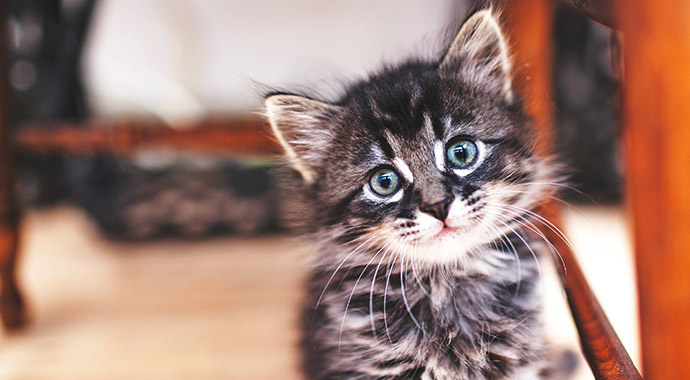

In [2]:
from PIL import Image

print('Тип данного контента: ', type(Image))

with Image.open('cat.jpeg') as img:
  img.load()
  print('Тип данного контента: ', type(img))


display(img) # Это функция Google Colab

## Измененние размера

Исследуем простейшие функции для изменения размера изображения:
* crop - обрезка изображения
* resize - приведение размера изображения к новым ширине и высоте
* reduce - масштабирование пропорционально коэффициенту
* thumbnail - изменяет сам объект изображения, не создает копию. Приводит к созданию миниатюры

In [3]:
print(img.size)

(690, 380)


In [ ]:
crop_img = img.crop((200, 10, 650, 350))
crop_img

In [ ]:
nw, nh = img.width // 3, img.height // 3
resize_img = img.resize((nw, nh))
resize_img

Для сохранения изображения используется функция `save`

In [6]:
resize_img.save('resized.png')

In [ ]:
# reduce
for factor in range(2, 8):
  reduce_img = img.reduce(factor)
  display(reduce_img)
  print()

In [ ]:
# thumbnail
img1=img.copy()
img1.thumbnail((200,100))
img1

## Трансформации

Для простейших преобразований можно воспользоваться методом `transpose()`



In [ ]:
# Image.FLIP_TOP_BOTTOM Image.FLIP_LEFT_RIGHT
# Image.FLIP_TOP_BOTTOM Image.ROTATE_90
# Image.ROTATE_180 Image.ROTATE_270
tr_img = crop_img.transpose(Image.ROTATE_90)
tr_img

In [ ]:
r_img = crop_img.rotate(45, expand=True)
r_img

## Слои, форматы, градации

Для конвертации изображения используется функция convert(mode). Возможные значения mode:
* 1 (1-bit pixels, black and white, stored with one pixel per byte)

* L (8-bit pixels, black and white)

* P (8-bit pixels, mapped to any other mode using a color palette)

* RGB (3x8-bit pixels, true color)

* RGBA (4x8-bit pixels, true color with transparency mask)

* CMYK (4x8-bit pixels, color separation)

* YCbCr (3x8-bit pixels, color video format)

* LAB (3x8-bit pixels, the L*a*b color space)

* HSV (3x8-bit pixels, Hue, Saturation, Value color space)

* I (32-bit signed integer pixels)

* F (32-bit floating point pixels)

In [ ]:
print(img.getbands())
cmyk_img = img.convert('L')
print(cmyk_img.getbands())
cmyk_img

Функция split() позволяет разделить изображение на каналы. Количество каналов определяется форматом изображения

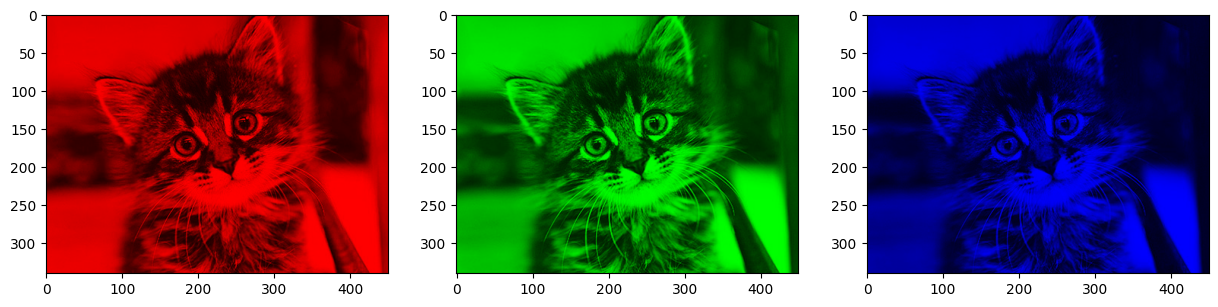

In [12]:
from matplotlib import pyplot as plt

# Выполним визуализацию зеленого, красного и синего канала для изображения RGB
red, green, blue = crop_img.split()

zeros = red.point(lambda _: 0)
red_image=Image.merge('RGB', (red, zeros, zeros))
green_image=Image.merge('RGB', (zeros, green, zeros))
blue_image=Image.merge('RGB', (zeros, zeros, blue))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,6))
axes[0].imshow(red_image)
axes[1].imshow(green_image)
axes[2].imshow(blue_image)

In [ ]:
# Конвертируем изображение в формат CMYC
cmyk_image=crop_img.convert('CMYK')
# Выполним визуализацию каналов для изображения CMYK
C, M, Y, K = cmyk_image.split()

zeros = red.point(lambda _: 0)
c_image=Image.merge('CMYK', (C, zeros, zeros, zeros))
m_image=Image.merge('CMYK', (zeros, M, zeros, zeros))
y_image=Image.merge('CMYK', (zeros, zeros, Y, zeros))
k_image=Image.merge('CMYK', (zeros, zeros, zeros, K))

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20,5))
axes[0].imshow(c_image)
axes[1].imshow(m_image)
axes[2].imshow(y_image)
axes[3].imshow(k_image)

## Фильтры

В библиотеке Pillow доступно большое количество фильтров различного назначения

In [15]:
from PIL import ImageFilter

In [ ]:
# Некоторые из доступных в библиотеке Pillow фильтров

filters = [ImageFilter.BLUR, ImageFilter.SHARPEN, ImageFilter.SMOOTH, ImageFilter.FIND_EDGES, ImageFilter.EDGE_ENHANCE, ImageFilter.EDGE_ENHANCE_MORE, ImageFilter.EMBOSS, ImageFilter.CONTOUR, ImageFilter.DETAIL]

columns, rows = 3, 3
fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(24,20))

for i in range(rows):
  for j in range(columns):
    axes[i, j].imshow(crop_img.filter(filters[i*3+j]))
    axes[i, j].set_title(filters[i*3+j])
fig.show()

Фильтров достаточно много, но программист может сформировать собственное ядро фильтра для преобразования изображения. Можно реализовывать фильтры с использованием сверток размером 3x3 или 5x5

In [ ]:
#  Применим пользовательский фильтр к изображению

import numpy as np

kernel3x3 = [-10,-1,-10,
          -1,20,-1,
          -10,-1,-10]

kernel5x5 = [10,-1,-1,-1,-10,
             -1,5,-1,-7,-1,
             -1,-1,10,-1,-1,
             -1,-7,-1,5,-1,
             -7,-1,-1,-1,10]

scale = None
offset=0.0


f_image1 = crop_img.filter(ImageFilter.Kernel(size=(5,5), kernel=kernel5x5, scale=scale, offset=offset))
f_image2 = crop_img.filter(ImageFilter.Kernel(size=(3,3), kernel=kernel3x3, scale=scale, offset=offset))

filterred_imagefig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,4))
axes[0].imshow(f_image1)
axes[0].set_title('Фильтр 5x5')
axes[1].imshow(f_image2)
axes[1].set_title('Фильтр 3x3')
axes[2].imshow(crop_img)
axes[2].set_title('Исходное')
filterred_imagefig.show()

## Color reduction (дискретизация палитры)

Изображения можно преобразовать путем уменьшения количества цветов (color reduction). К пикселям изображения применяется цнлочисленное деление, а затем - умножение на делитель. В качестве значений цветов получаются не непрерывные величины, а дикретные значения, а количество цветов - уменьшается

In [ ]:
im = np.array(crop_img)

im_32 = im // 32 * 32
im_64 = im // 64 * 64
im_128 = im // 128 * 128

im_dec = np.concatenate((im, im_32, im_64, im_128), axis=1)
Image.fromarray(im_dec)

## Инвертирование изображения

In [ ]:
im = np.array(crop_img)
im_i = 255 - im
im_dec = np.concatenate((im, im_i), axis=1)
Image.fromarray(im_dec)

## Гамма-коррекция

С изображениями допустимы любые преобразования за счет выполнения арифметических операций над числовыми значениями пикселей. Например, можно реализовать гамма-коррекцию

In [ ]:
im = np.array(crop_img, np.float32)

im_1_42 = 255.0 * (im / 255.0)**(1 / 4.2)
im_42 = 255.0 * (im / 255.0)**4.2

im_gamma = np.concatenate((im_1_42, im, im_42), axis=1)
Image.fromarray(np.uint8(im_gamma))

## Обрезка изображения на основе срезов массивов

Вместо использования метода crop возможно подрезать изображение с использованием среза матрицы

In [ ]:
im = np.array(crop_img)
print('Исходный размер', im.shape)
im_trim1 = im[100:200, 150:300]
print('Размер обрезанного изображения', im_trim1.shape)
Image.fromarray(im_trim1)

За счет простых операций можно реализовать следующий эффект

In [ ]:
src = np.array(crop_img)
dst = np.array(crop_img) // 5

dst_copy = dst.copy()
dst_copy[100:200, 150:300] = src[100:200, 150:300]

Image.fromarray(dst_copy)

# Контрольные вопросы

Ответы на контрольные вопросы с кодом ....